In [1]:
import sys
sys.path.append("../")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import book_format
book_format.set_style()

## 0 Scope of the Chapter 6

- 이번 단원에서는 Newton's equation of motion에 대한 Kalman filter를 설계한다.
    - 거창하게 말했지만 또 tracking a dog 하겠다는 이야기.
    - 처음부터 일반화된 알고리즘을 소개하면 어렵기 때문에 예제를 통해 알고리즘을 이해하는데에 중점을 두고 논의 진행.
    - 일반화된 알고리즘은 다음 단원에서 구체적인 식과 함께 소개할 예정.

## 1 Newton's Equation of Motion

- Constant velocity: $x = vt + x_0$
- Constant acceleration: $x = \frac{1}{2}at^2 + v_0t + x_0$
- Constant jerk: $x = \frac{1}{6}jt^3 +  \frac{1}{2}a_0 t^2 + v_0 t + x_0$
- ...

## 2 1D Kalman Filter 복습

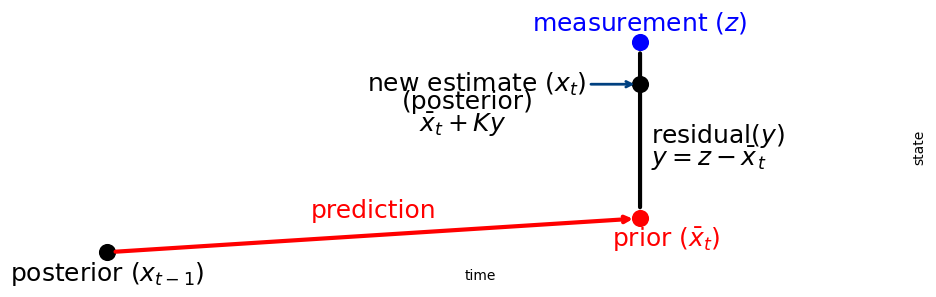

In [2]:
import kf_book.book_plots as book_plots
book_plots.show_residual_chart()

배운 내용을 정리하면 Kalman Filter는 다음과 같다.

<u>Predict</u>

$\begin{array}{|l|l|l|}
\hline
\text{Equation} & \text{Implementation} & \text{Kalman Form}\\
\hline
 \bar x = x + f_x & \bar\mu = \mu + \mu_{f_x} & \bar x = x + dx\\
& \bar\sigma^2 = \sigma^2 + \sigma_{f_x}^2 & \bar P = P + Q\\
\hline
\end{array}$

<u>Update</u>

$\begin{array}{|l|l|l|}
\hline
\text{Equation} & \text{Implementation}& \text{Kalman Form}\\
\hline
 x = \| \mathcal L\bar x\| & y = z - \bar\mu & y = z - \bar x\\
 & K = \frac {\bar\sigma^2} {\bar\sigma^2 + \sigma_z^2} & K = \frac {\bar P}{\bar P+R}\\
 & \mu = \bar \mu + Ky & x = \bar x + Ky\\
 & \sigma^2 = \frac {\bar\sigma^2 \sigma_z^2} {\bar\sigma^2 + \sigma_z^2} & P = (1-K)\bar P\\
\hline
\end{array}$

- $K$는 Kalman gain

## 3 Multivariate Kalman Fiter

- 1차원 Kalman filter와 개념은 동일
    -  Use a Gaussian to represent our estimate of the state and error
    -  Use a Gaussian to represent the measurement and its error
    -  Use a Gaussian to represent the process model
- 다차원으로 확장하는 과정에서 몇 가지 처음보는 텀이 등장하지만, 이 장에서는 개념적으로만 설명하고 넘어갈 예정.

<u>**Predict**</u>

$\begin{array}{|l|l|l|}
\hline
\text{Univariate} & \text{Univariate} & \text{Multivariate}\\
& \text{(Kalman form)} & \\
\hline
\bar \mu = \mu + \mu_{f_x} & \bar x = x + dx & \bar{\mathbf x} = \mathbf{Fx} + \mathbf{Bu}\\
\bar\sigma^2 = \sigma_x^2 + \sigma_{f_x}^2 & \bar P = P + Q & \bar{\mathbf P} = \mathbf{FPF}^\mathsf T + \mathbf Q \\
\hline
\end{array}$

$\mathbf x,\, \mathbf P$: state mean과 covariance. $x$와 $\sigma^2$에 해당.

$\mathbf F$: state transition function. $\bf x$에 곱해서 state를 진행시킴.

$\mathbf Q$: process covariance. $\sigma^2_{f_x}$에 해당.

$\mathbf B$, $\mathbf u$: 다차원 모델에서 새로 등장한 항들. 시스템에 대한 제어(?)를 모델링하는 항들.

<u>**Update**</u>

$\begin{array}{|l|l|l|}
\hline
\text{Univariate} & \text{Univariate} & \text{Multivariate}\\
& \text{(Kalman form)} & \\
\hline
& y = z - \bar x & \mathbf y = \mathbf z - \mathbf{H\bar x} \\
& K = \frac{\bar P}{\bar P+R}&
\mathbf K = \mathbf{\bar{P}H}^\mathsf T (\mathbf{H\bar{P}H}^\mathsf T + \mathbf R)^{-1} \\
\mu=\frac{\bar\sigma^2\, \mu_z + \sigma_z^2 \, \bar\mu} {\bar\sigma^2 + \sigma_z^2} & x = \bar x + Ky & \mathbf x = \bar{\mathbf x} + \mathbf{Ky} \\
\sigma^2 = \frac{\sigma_1^2\sigma_2^2}{\sigma_1^2+\sigma_2^2} & P = (1-K)\bar P &
\mathbf P = (\mathbf I - \mathbf{KH})\mathbf{\bar{P}} \\
\hline
\end{array}$

$\mathbf H$: measurement function. $\bar x$에 곱해서 알아내려 하는 값을 계산.

$\mathbf z,\, \mathbf R$: measurement mean과 noise covariance. 1차원 Kalman filter의 $z$와 $\sigma_z^2$에 해당

$\mathbf y$, $\mathbf K$: residual, Kalman gain.

## 4 Tracking a Dog Problem

- 이전과 같이 강아지 위치 추적 문제를 풀 예정.
- 이번에는 위치뿐만이 아니라 속도까지 추적하는 다차원 문제로 확장해서 풀어볼 예정.
- 아래 함수는 문제를 풀기 위한 데이터 생성 함수.
    - `z_var`: measurement 분산
    - `process_var`: process 분산
    - `count`: count step만큼 시뮬레이션

In [3]:
import math
import numpy as np
from numpy.random import randn

def compute_dog_data(z_var, process_var, count=1, dt=1.):
    "returns track, measurements 1D ndarrays"
    x, vel = 0., 1.
    z_std = math.sqrt(z_var) 
    p_std = math.sqrt(process_var)
    xs, zs = [], []
    for _ in range(count):
        v = vel + (randn() * p_std)
        x += v*dt        
        xs.append(x)
        zs.append(x + randn() * z_std)        
    return np.array(xs), np.array(zs)

### 4.1 데이터 예시

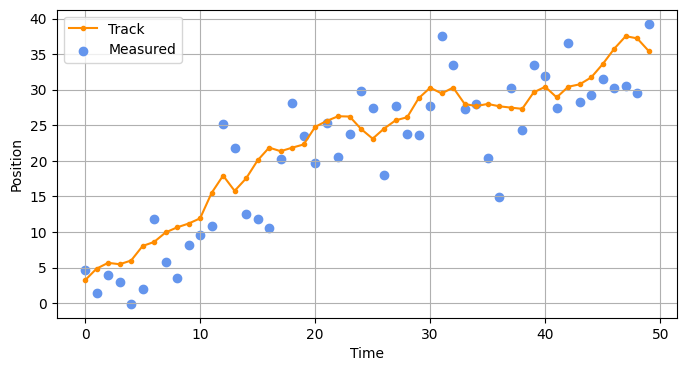

In [11]:
t = np.arange(50)
trk, zs = compute_dog_data(30, 1.5, 50, 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(t, zs, c="cornflowerblue", label="Measured")
ax.plot(t, trk, ".-", c="darkorange", label="Track")
ax.set_xlabel("Time")
ax.set_ylabel("Position")
ax.grid()
ax.legend()
plt.show()

## 5 Prediction Step

### 5.1 Design State Variable
- 1차원 문제에서는 위치만 추적했다. 이번에는 속도까지 추적하기 위해 state variable을 벡터로 확장할 것이다.
    - $\mathbf x =\begin{bmatrix}x \\ \dot x\end{bmatrix} = \begin{bmatrix} 10.0 \\ 4.5 \end{bmatrix}$
    - 초기 위치는 10, 초기 속도는 4.5 m/s
- 참고로 $\mathbf x$는 Kalman filter literature에서 state variable을 나타내기 위해 쓰이는 문자. 지금 이 문제에 position $x$가 등장해 햇갈릴 수 있지만, 서로 다른 변수이다.
    - 예를들어 우리가 강아지의 y 좌표를 추적하려고 할 때 state variable을 $\mathbf y =\begin{bmatrix}y & \dot y\end{bmatrix}^\mathsf T$로 쓰는것보다 $\mathbf x =\begin{bmatrix}y & \dot y\end{bmatrix}^\mathsf T$로 쓰는것이 자연스러운 표기.

### 5.2 Design State Covariance
- State Covariance는 $\mathbf P$로 표기
- 초기 상태에 대해 reasonable한 가정을 하기 위해 몇 가지 사항 고려
    - 초기 위치에 대해 확신이 거의 없다고 가정하고 $\sigma_\mathtt{pos}^2=500 m^2$로 설정.
    - 강아지의 최고 속력이 21 m/s정도인 것을 감안해서 속도에 대한 분산 설정: $3\sigma_\mathtt{vel}=21$ &#8594; $\sigma_\mathtt{vel}^2=7^2=49$.
    - 위치와 속도 사이에 correlation이 있지만, 강아지위 위치와 속도 사이의 관계에 대해 지식이 없다고 가정하고 초기값을 0으로 설정

$$
\mathbf P = \begin{bmatrix}500 & 0 \\ 0&49\end{bmatrix}
$$

### 5.3 Design Process Model
- Newton's Equation에 기반하여 process model을 행렬$\mathbf F$로 표현.
- 우리가 설계해야 하는 것은...

$$\mathbf{\bar x} = \mathbf{Fx}$$

$$\begin{bmatrix} \bar x \\ \dot{\bar x}\end{bmatrix} = \begin{bmatrix}? & ? \\? & ?\end{bmatrix}\begin{bmatrix}x\\\dot x\end{bmatrix}$$

- Newton's Equation에 따르면
    - $\bar x = x + \dot x \Delta t$
    - $\bar{\dot x} = \dot x$ (속도는 일정하다고 가정)
    
- 따라서 process model $\mathbf{F}$는

$$
\mathbf F = \begin{bmatrix}1 & \Delta t \\ 0&1\end{bmatrix}
$$

### 5.4 Design Process Noise
- Process noise는 covariance matrix $\mathbf Q$로 표기.
- 1차원 케이스와 마찬가지로 prediction 과정에서 state covariance에 더해짐 (식 유도과정은 서로 다르지만 본질적으로 같은 이유 때문에 식의 형태가 같음).
    - 자세한 수학적인 내용은 다음 단원에서 소개한다고 함.

### 5.5 Control Function
- Kalman filter를 이용해 데이터를 필터링하는 과정에서 tracking하는 object에 대한 컨트롤도 고려한다.
    - 예를들어 로봇을 조종하다고 할 때, 우리가 매 스탭 로봇을 어느 방향/속도로 움직였는지에 대한 정보도 고려해야 한다.
    - 이 정보는 prediction step에서 고려하는 것이 적절하다.
- $\mathbf u$를 control input, $\mathbf B$를 control function(control input이 어떠한 방식으로 영향을 미치는지)이라고 할 때 prediction에 다음과 같이 반영된다.

$$\mathbf{\bar x} = \mathbf{Fx} + \mathbf{Bu}$$

## 6 Update Step

### 6.1 Design Measurement Function
- 이전 단원에서도 본 것처럼, 위치 추적 문제에서 측정은 간단하다. 현재 우리가 추정하는 위치에서 실체 측정값을 빼서 차이를 계산하면 된다.

$$ \mathtt{residual} = \mathtt{measured\, \, position} - \mathtt{predicted\, \, position}$$

- 하지만, 전압을 측정하고 온도를 트래킹하는 문제이서 이와 같은 방법을 쓸 수 없다.

$$ \mathtt{residual} = \mathtt{voltage(measured)} - \mathtt{temperature(predicted)}\;\;\;(NONSENSE!)$$

- 이를 일반화시키기 위해 Kalman filter에서는 state를 measurement space와 같은 space로 변환하는 함수$\mathbf H$가 필요하다.

$$\mathbf y = \mathbf z - \mathbf{H \bar x}$$

- 지금 풀고있는 강아지 위치 추적 문제는 $\mathbf H=\begin{bmatrix}1&0\end{bmatrix}$인 경우이다.

$$\begin{aligned}
\textbf{y} &= \mathbf z - \begin{bmatrix}1&0\end{bmatrix} \begin{bmatrix}x \\ \dot x\end{bmatrix} \\
&= [z] - [x]
\end{aligned}$$

### 6.2 Design Measurement
- Measurement는 $\mathbf z$로, measurement covariance는 $\mathbf R$로 표기한다.
- 지금 푸는 문제의 경우 위치만 측정 가능하고 속도는 hidden variable이라 가정한다. 따라서 $\mathbf R$은 원소가 하나인 행렬이다.

$$R = \begin{bmatrix}\sigma^2_z\end{bmatrix} = \begin{bmatrix}5\end{bmatrix}$$

- 만약 여러개의 센서를 이용해 위치의 x좌표, y좌표를 따로 측정하는 등 measurement의 차원이 늘어나는 경우 covariance matrix의 차원도 늘어난다.

## 7 Implementation
Kalman filter는 `filterpy.kalman.KalmanFilter`에 구현되어 있다. 여기에서는 이 클래스를 이용해 위에서 우리가 디자인한 문제를 풀어볼 예정이다.

시작하기 전 문자를 다시 정리하자면
- $\mathbf x$: state vector
- $\mathbf P$: state covariance
- $\mathbf F$: process model
- $\mathbf Q$: process covariance
- $\mathbf u$: control input
- $\mathbf B$: control function
- $\mathbf H$: measurement function
- $\mathbf R$: measurement covariance

### 7.1 Initialize Kalman Filter

In [5]:
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def pos_vel_filter(x, P, R, Q=0., dt=1.0):
    """ Returns a KalmanFilter which implements a
    constant velocity model for a state [x dx].T
    """
    
    kf = KalmanFilter(
        dim_x=2,  # State vector의 차원은 2차원 (위치, 속도)
        dim_z=1,  # Measurement의 차원은 1차원 (위치)
    )
    kf.x = np.array([x[0], x[1]]) # 초기 위치와 속도를 초기화
    kf.F = np.array([[1., dt],
                     [0.,  1.]])  # State transition function
    kf.H = np.array([[1., 0]])    # Measurement function
    kf.R *= R                     # Measurement uncertainty (초기값이 단위행렬이라 초기값에 곱함)
    if np.isscalar(P):
        kf.P *= P                 # covariance matrix 
    else:
        kf.P[:] = P               # [:] makes deep copy
    if np.isscalar(Q):
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q)
    else:
        kf.Q[:] = Q
    return kf

In [6]:
kf = pos_vel_filter(x=np.array([0., 0.]), P=500, R=5, Q=0.1, dt=1)
display(kf)

KalmanFilter object
dim_x = 2
dim_z = 1
dim_u = 0
x = [0. 0.]
P = [[500.   0.]
     [  0. 500.]]
x_prior = [[0. 0.]].T
P_prior = [[1. 0.]
           [0. 1.]]
x_post = [[0. 0.]].T
P_post = [[1. 0.]
          [0. 1.]]
F = [[1. 1.]
     [0. 1.]]
Q = [[0.025 0.05 ]
     [0.05  0.1  ]]
R = [[5.]]
H = [[1. 0.]]
K = [[0. 0.]].T
y = [[0.]]
S = [[0.]]
SI = [[0.]]
M = [[0.]]
B = None
z = [[None]]
log-likelihood = -708.3964185322641
likelihood = 2.2250738585072014e-308
mahalanobis = 0.0
alpha = 1.0
inv = <function inv at 0x126980ee0>

### 7.2 Run Kalman Filter to track the dog

In [29]:
from kf_book.mkf_internal import plot_track

def run(x0=(0.,0.), P=500, R=0, Q=0, dt=1.0, 
        track=None, zs=None,
        count=0, do_plot=True, **kwargs):
    """
    track is the actual position of the dog, zs are the 
    corresponding measurements. 
    """

    # Simulate dog if no data provided. 
    if zs is None:
        track, zs = compute_dog_data(R, Q, count)

    # create the Kalman filter
    kf = pos_vel_filter(x0, R=R, P=P, Q=Q, dt=dt)  

    # run the kalman filter and store the results
    xs, cov = [], []
    for z in zs:
        kf.predict()     # Porcess model, process covariance를 이용하여 다음 위치를 예측
        kf.update(z)     # 측정된 위치 z를 이용하여 state vector와 state covariance를 보정
        xs.append(kf.x)  # 보정된 state를 저장
        cov.append(kf.P) # 보정된 state covariance를 저장

    xs, cov = np.array(xs), np.array(cov)
    if do_plot:
        plot_track(xs[:, 0], track, zs, cov, **kwargs)
    return xs, cov

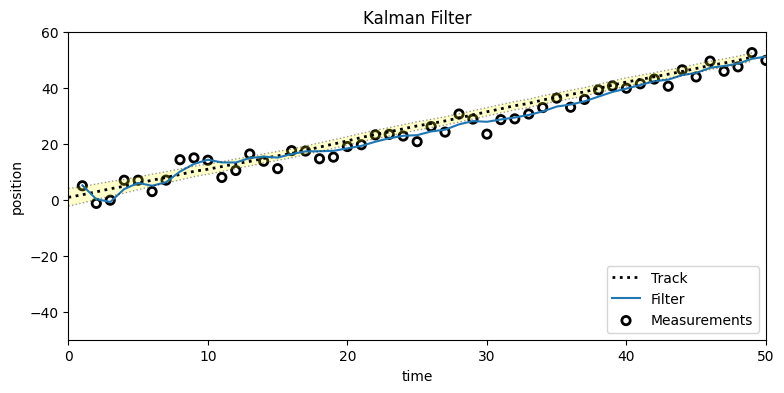

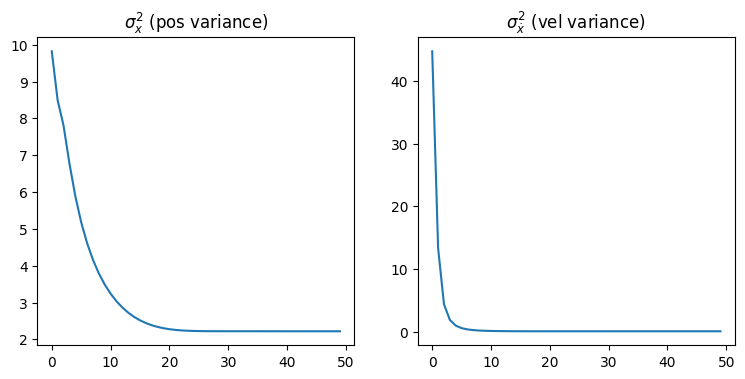

In [30]:
x0 = (10, 4.5)
P = np.diag([500., 49.])
Ms, Ps = run(
    count=50,  # 50 스탭동안 추정
    x0=x0,     # 초기 state vector
    P=P,       # 초기 state covariance
    R=10,      # Measurement covariance
    Q=0.01,    # Process covariance
)

- 가장 위쪽 그래프에서 Track은 강아지의 실제 위치, 노란색 영역은 filter의 1 std, 파란색 선은 추정한 실제 위치이다.
- 아래 그래프는 시간에 따라 state vector의 위치와 속도에 대한 분산이 어떻게 변화하는지 보여준다.
- 시간이 지남에 따라 위치와 속도를 점점 더 정확하게 추적하는 것을 볼 수 있다.

## 8 Effect of Hidden Variables
- 위에서 강아지 위치 추적 문제를 풀 때 속도라는 hidden variable까지 포함하여 multivariate Kalmanfilter를 이용하였다.
- 사실 문제 자체는 1차원 Kalman filter를 사용했을 때랑 똑같다. 그럼 속도를 hidden variable로 도입해서 다차원 Kalmanfilter를 사용하는 것이 의미가 있는걸까?

In [31]:
from math import sqrt
from numpy.random import randn

def pos_vel_filter_control(x, P, R, Q=0., dt=1.0):
    """ Returns a KalmanFilter which implements a
    constant velocity model for a state [x dx].T
    """
    
    kf = KalmanFilter(
        dim_x=2,  # State vector의 차원은 2차원 (위치, 속도)
        dim_z=1,  # Measurement의 차원은 1차원 (위치)
    )
    kf.x = np.array([x[0], x[1]]) # 초기 위치와 속도를 초기화
    kf.F = np.array([[1., dt],
                     [0.,  1.]])  # State transition function
    kf.H = np.array([[1., 0]])    # Measurement function
    kf.R *= R                     # Measurement uncertainty (초기값이 단위행렬이라 초기값에 곱함)
    if np.isscalar(P):
        kf.P *= P                 # covariance matrix 
    else:
        kf.P[:] = P               # [:] makes deep copy
    if np.isscalar(Q):
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q)
    else:
        kf.Q[:] = Q
    kf.B = np.array([[1.]])
    return kf


def univariate_filter(x0, P, R, Q):
    f = KalmanFilter(dim_x=1, dim_z=1, dim_u=1)
    f.x = np.array([[x0]])
    f.P *= P
    f.H = np.array([[1.]])
    f.F = np.array([[1.]])
    f.B = np.array([[1.]])
    f.Q *= Q
    f.R *= R
    return f

def plot_1d_2d(xs, xs1d, xs2d):
    plt.plot(xs1d, label='1D Filter')
    plt.scatter(range(len(xs2d)), xs2d, c='r', alpha=0.7, label='2D Filter')
    plt.plot(xs, ls='--', color='k', lw=1, label='track')
    plt.title('State')
    plt.legend(loc=4)
    plt.show()
    
def compare_1D_2D(x0, P, R, Q, vel, u=None):
    """
    초기 위치가 0에서 시작하여 속도 vel로 움직이는 강아지를 추적 (dt = 1이라고 가정)
    
    위치만을 추적하는 1차원 필터 f1D와 hidden variable로 속도까지 이용하는
    f2D를 사용하여 위치를 추적하고 결과를 비교.
    """
    # storage for filter output
    xs, xs1, xs2 = [], [], []

    # 1d KalmanFilter
    f1D = univariate_filter(x0, P, R, Q)

    #2D Kalman filter
    f2D = pos_vel_filter_control(x=(x0, vel), P=P, R=R, Q=Q)
    if np.isscalar(u):
        u = [u]
    pos = 0 # true position
    for i in range(100):
        pos += vel # dt = 1
        xs.append(pos)

        # control input u - discussed below
        f1D.predict(u=u)
        f2D.predict(u=u)
        
        z = pos + randn()*sqrt(R) # measurement
        f1D.update(z)
        f2D.update(z)
        
        xs1.append(f1D.x[0])
        xs2.append(f2D.x[0])
    plt.figure()
    plot_1d_2d(xs, xs1, xs2)

### 8.1 실험 1

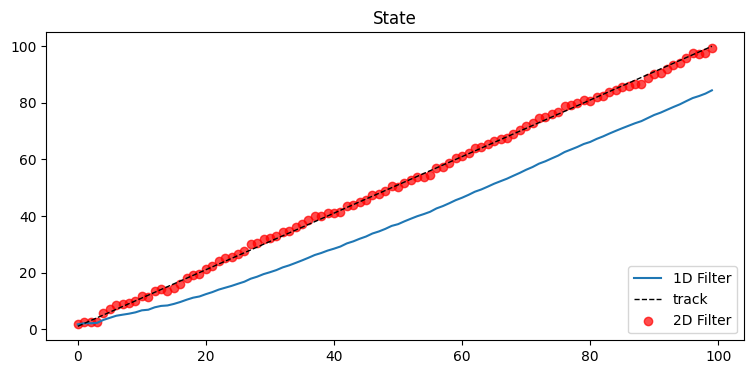

In [11]:
compare_1D_2D(
    x0=0,   # 초기 위치에 대한 가정
    P=50.,  # 초기 state covariance에 대한 가정
    R=5.,   # Measurement covariance
    Q=.02,  # Process covariance
    vel=1., # 강아지의 실제 속도
)

- 1D 모델은 속도에 대한 추정을 하지 않기 때문에 점점 오차가 커지는 것을 볼 수 있음.

### 8.2 실험 2: 1D 모델에 강아지의 움직임에 대한 정보를 제공할 경우
- `compare_1D_2D` 함수를 보면 control input `u`를 이용해 1D model에 강아지의 움직임에 대한 정보를 줄 수 있도록 구현되어 있다 (2D model에는 해당 정보가 제공되지 않음).
- 이 변수를 통해 1D model에 강아지의 움직임에 대한 정보를 제공하고, 정보가 정확한 경우와 그렇지 않은 경우의 결과를 살펴보자.

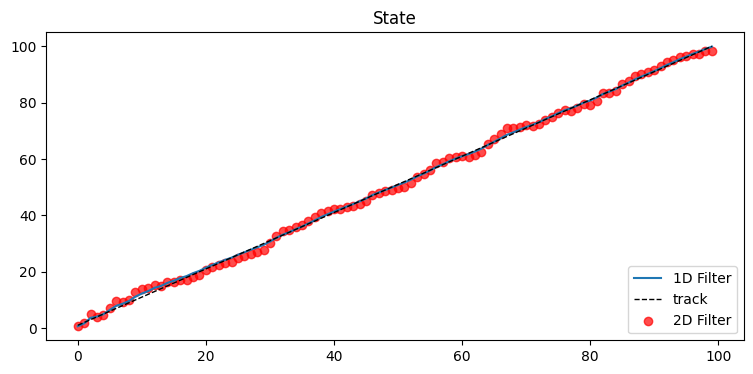

In [12]:
# 실제 강아지의 속도도 1, 1D 모델에 제공한 속도도 1. 정확한 정보를 제공한 경우
compare_1D_2D(
    x0=0,   # 초기 위치에 대한 가정
    P=50.,  # 초기 state covariance에 대한 가정
    R=5.,   # Measurement covariance
    Q=.02,  # Process covariance
    vel=1., # 강아지의 실제 속도
    u=1.
)

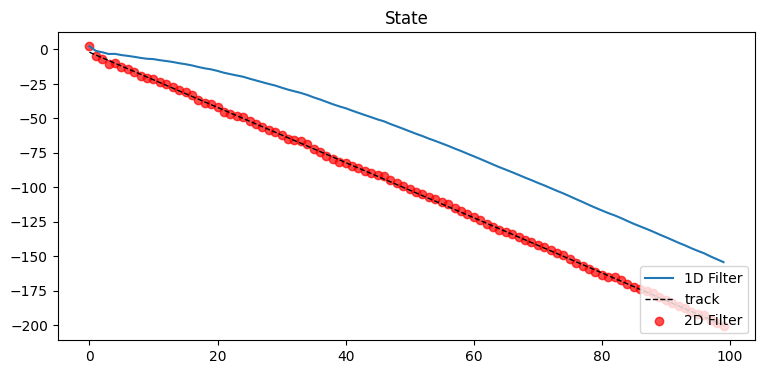

In [13]:
# 실제 강아지의 속도는 -2, 1D 모델에 제공한 속도도 1. 부정확한 정보를 제공한 경우
compare_1D_2D(
    x0=0,   # 초기 위치에 대한 가정
    P=50.,  # 초기 state covariance에 대한 가정
    R=5.,   # Measurement covariance
    Q=.02,  # Process covariance
    vel=-2., # 강아지의 실제 속도
    u=1.
)

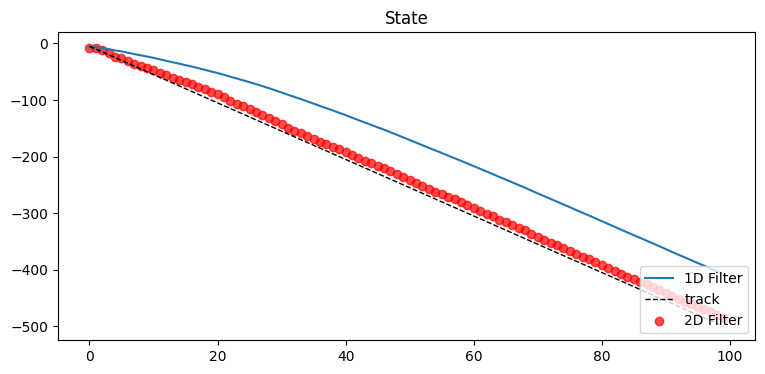

In [39]:
# 실제 강아지의 속도는 -5, 1D 모델에 제공한 속도도 1. 부정확한 정보를 제공한 경우
compare_1D_2D(
    x0=0,   # 초기 위치에 대한 가정
    P=50.,  # 초기 state covariance에 대한 가정
    R=5.,   # Measurement covariance
    Q=.02,  # Process covariance
    vel=-5., # 강아지의 실제 속도
    u=1.
)

- 결과를 보면, 정확한 정보를 제공한 경우 2D filter만큼 정확히 추적하지만, 정보가 잘못된 경우 굉장히 부정확하게 추적하는 것을 볼 수 있다.
- 정확한 사전정보를 알기 힘든 경우가 많으므로 hidden variable을 도입하는 것이 의미있다.

## 9 Initial State Covariance의 영향
- Kalman filter에 초기 상태 추정에 대한 covariance $\mathbf P$를 제공해야 한다.
- 이 초기 covariance를 어떤 값으로 제공하는지에 따라 추적 결과가 크게 달라지는데, 몇 가지 케이스를 통해 확인해도록 하자.
- 실험 결과를 공평하게 비교하기 위해 강아지 데이터를 아래처럼 미리 만들어 고정한 후 실험할 것이다.

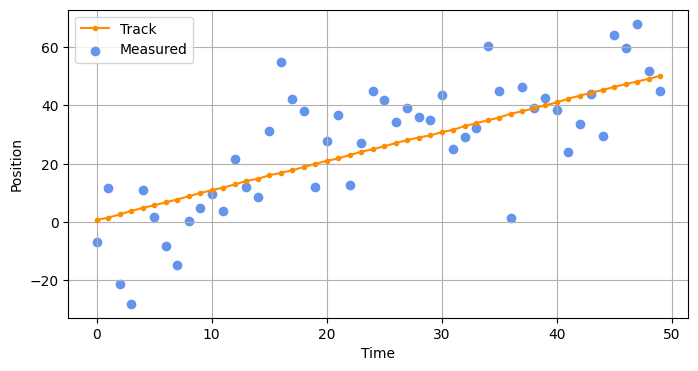

In [40]:
trk, zs = compute_dog_data(z_var=225, process_var=.02, count=50)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(range(50), zs, c="cornflowerblue", label="Measured")
ax.plot(trk, ".-", c="darkorange", label="Track")
ax.grid()
ax.set_xlabel("Time")
ax.set_ylabel("Position")
ax.legend()
plt.show()

### 9.1 정확한 초기 위치를 아는 경우
- 실제 초기 위치가 0이고 알고리즘의 초기 위치를 0으로 설정한 경우

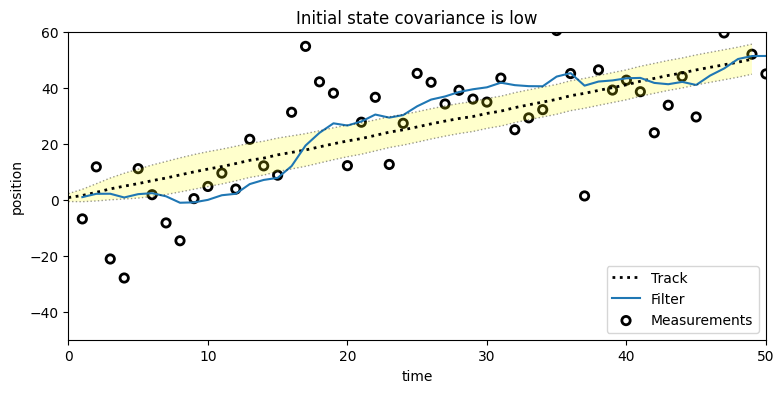

In [41]:
_, _ = run(track=trk, zs=zs, R=225, x0=(0, 1), Q=.02, P=1, plot_P=False,
    title='Initial state covariance is low')

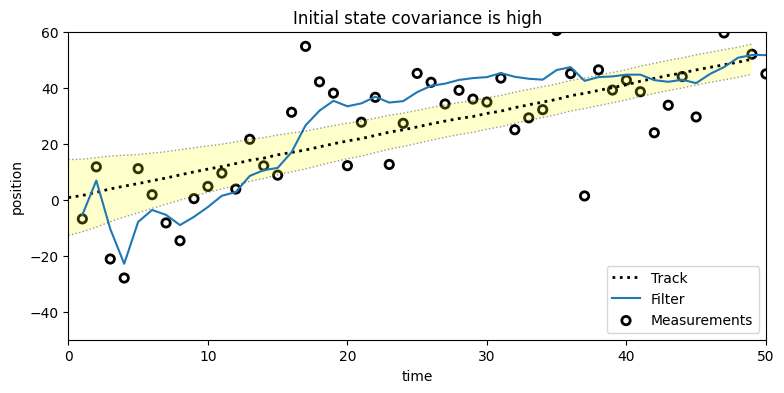

In [42]:
_, _ = run(track=trk, zs=zs, R=225, x0=(0, 1), Q=.02, P=500, plot_P=False,
    title='Initial state covariance is high')

- 초반 결과가 약간 다르지만 시간이 지나면 잘 추적하는 것을 볼 수 있다

### 9.2 초기 위치에 대한 가정이 크게 잘못된 경우
- 실제 초기 위치가 0이고 알고리즘의 초기 위치를 100으로 설정한 경우

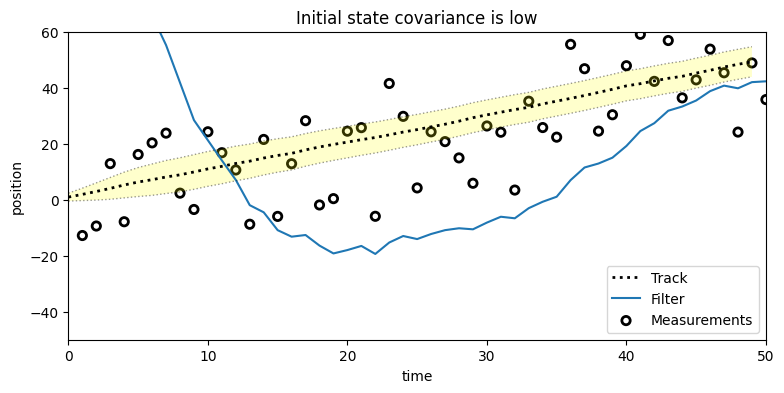

In [17]:
_, _ = run(track=trk, zs=zs, R=225, x0=(100, 1), Q=.02, P=1, plot_P=False,
    title='Initial state covariance is low')

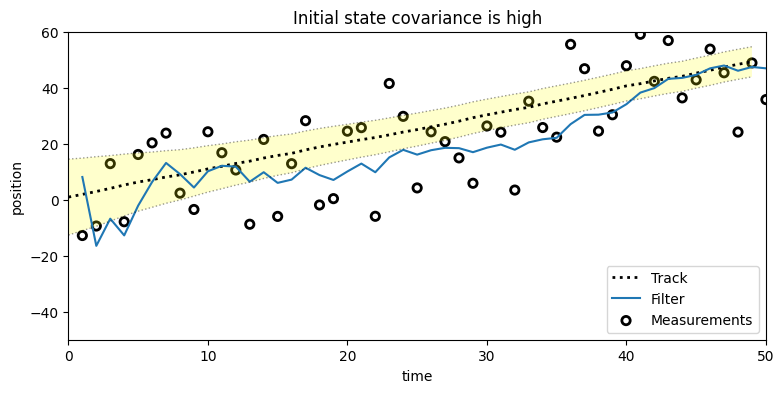

In [18]:
_, _ = run(track=trk, zs=zs, R=225, x0=(100, 1), Q=.02, P=500, plot_P=False,
    title='Initial state covariance is high')

- 초기 위치에 대한 가정이 크게 잘못된 경우 너무 작은 covariance를 가정하면 추적이 잘 되지 않는것을 볼 수 있다.